<a href="https://colab.research.google.com/github/ran-nope/DSA_PROJECT/blob/main/DSA_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
WEEK 1 : TEAM FORMATION & DATA HUNTING
Syllabus Mapping : Unit 1
----------------------------------------------------------------
Goals for this week:
    1. Select the dataset (Google Play Store Apps - Kaggle)
    2. Set up the GitHub repository for the project
    3. Get comfortable with the two core libraries we will use
       throughout the project: Pandas and NumPy

Dataset source:
    https://www.kaggle.com/datasets/lava18/google-play-store-apps
    File used: googleplaystore.csv
----------------------------------------------------------------
"""

import pandas as pd
import numpy as np



# 2. LOADING THE DATASET FOR THE FIRST TIME

DATA_PATH = "googleplaystore.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape of the dataset (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows of the dataset:")
print(df.head())

# 3. GETTING COMFORTABLE WITH PANDAS

print("\n--- Pandas basics ---")
print("Selecting a single column (App):")
print(df["App"].head())

print("\nSelecting multiple columns:")
print(df[["App", "Category", "Rating"]].head())

print("\nFiltering rows: apps with a Rating above 4.5")
high_rated = df[df["Rating"] > 4.5]
print(f"Number of apps rated above 4.5: {len(high_rated)}")

print("\nSorting apps by Rating (descending):")
print(df.sort_values(by="Rating", ascending=False)[["App", "Rating"]].head())

# 4. GETTING COMFORTABLE WITH NUMPY

print("\n--- NumPy basics ---")
ratings_array = df["Rating"].dropna().to_numpy()
print("Ratings converted to a NumPy array, sample:", ratings_array[:5])
print("Mean rating (NumPy):", np.mean(ratings_array))
print("Standard deviation of ratings (NumPy):", np.std(ratings_array))
print("Max rating:", np.max(ratings_array), "| Min rating:", np.min(ratings_array))

# A quick NumPy array operation demo
sample = np.array([1, 2, 3, 4, 5])
print("\nSample array:", sample)
print("Array squared:", sample ** 2)
print("Array mean:", sample.mean())

print("\nWeek 1 complete: dataset selected, repo initialised, "
      "and team is comfortable with Pandas/NumPy basics.")

Dataset loaded successfully!
Shape of the dataset (rows, columns): (10841, 13)

Column names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

First 5 rows of the dataset:
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  2156

In [ ]:
"""
WEEK 2 : "KNOW YOUR DATA"
Syllabus Mapping : Unit 1 (Practical)
----------------------------------------------------------------
Goals for this week:
    1. Load the dataset
    2. Check data types of every column
    3. Inspect the structure (shape, nulls, duplicates, uniques)
    4. Generate a "First Impression" report summarising the dataset
----------------------------------------------------------------
"""
import pandas as pd

DATA_PATH = "googleplaystore.csv"
df = pd.read_csv(DATA_PATH)


# 1. BASIC STRUCTURE

print("=" * 60)
print("BASIC STRUCTURE")
print("=" * 60)
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())

# 2. CHECKING DATA TYPES

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

# Note: Reviews, Size, Installs and Price look numeric but are
# stored as text (object) because of characters like "+", ",",
# "M", "$". This is exactly what we will fix in Week 3.

# 3. df.info() AND df.describe()

print("\n" + "=" * 60)
print("df.info()")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("df.describe() - numeric columns")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("df.describe(include='object') - categorical columns")
print("=" * 60)
print(df.describe(include="object"))


# 4. MISSING VALUES

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct.round(2)})
print(missing_report[missing_report["missing_count"] > 0])

# 5. DUPLICATES

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print("Number of fully duplicate rows:", df.duplicated().sum())
print("Number of duplicate App names:", df.duplicated(subset="App").sum())

# 6. UNIQUE VALUES IN KEY CATEGORICAL COLUMNS

print("\n" + "=" * 60)
print("UNIQUE VALUES - KEY COLUMNS")
print("=" * 60)
for col in ["Category", "Type", "Content Rating", "Genres"]:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))

# 7. "FIRST IMPRESSION" REPORT

print("\n" + "=" * 60)
print("FIRST IMPRESSION REPORT")
print("=" * 60)
report = f"""
Dataset          : Google Play Store Apps
Total records    : {df.shape[0]}
Total features   : {df.shape[1]}
Numeric columns  : {df.select_dtypes(include='number').columns.tolist()}
Text columns     : {df.select_dtypes(include='object').columns.tolist()}
Columns with missing data : {missing[missing > 0].index.tolist()}
Duplicate rows   : {df.duplicated().sum()}
Most common category : {df['Category'].mode()[0]}
Free vs Paid split : {df['Type'].value_counts().to_dict()}
Observations:
 - Reviews, Size, Installs, Price are stored as text and need cleaning.
 - Rating has missing values that will need imputation.
 - Category, Genres, Content Rating are categorical and can be
   used as grouping variables for later analysis.
"""
print(report)

with open("first_impression_report.txt", "w") as f:
    f.write(report)
print("Saved report to first_impression_report.txt")

BASIC STRUCTURE
Shape (rows, columns): (10841, 13)

Column names: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

DATA TYPES
App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 n

Shape before cleaning: (10841, 13)
Removed 483 duplicate rows.

Data types after cleaning:
Installs      int64
Price       float64
Size        float64
Reviews     float64
Rating      float64
dtype: object

DESCRIPTIVE STATISTICS (before imputation)
  Column        Mean   Median      Mode        Range     Variance     Std Dev      IQR  Skewness  Kurtosis
  Rating        4.19      4.3       4.4 1.800000e+01 3.000000e-01        0.55      0.5      0.64     65.42
 Reviews   405904.61   1680.0       0.0 7.815831e+07 7.272611e+12  2696777.84  46384.0     17.47    395.14
    Size       21.29     13.0      11.0 9.999000e+01 5.080800e+02       22.54     24.3      1.57      1.97
Installs 14156392.60 100000.0 1000000.0 1.000000e+09 6.437784e+15 80235800.68 999000.0     10.13    112.86
   Price        1.03      0.0       0.0 4.000000e+02 2.649900e+02       16.28      0.0     23.32    557.49

Reading the skewness column: values near 0 = roughly symmetric, positive = right-skewed (long tail of high v

/tmp/ipykernel_1079/342235805.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1000x500 with 0 Axes>

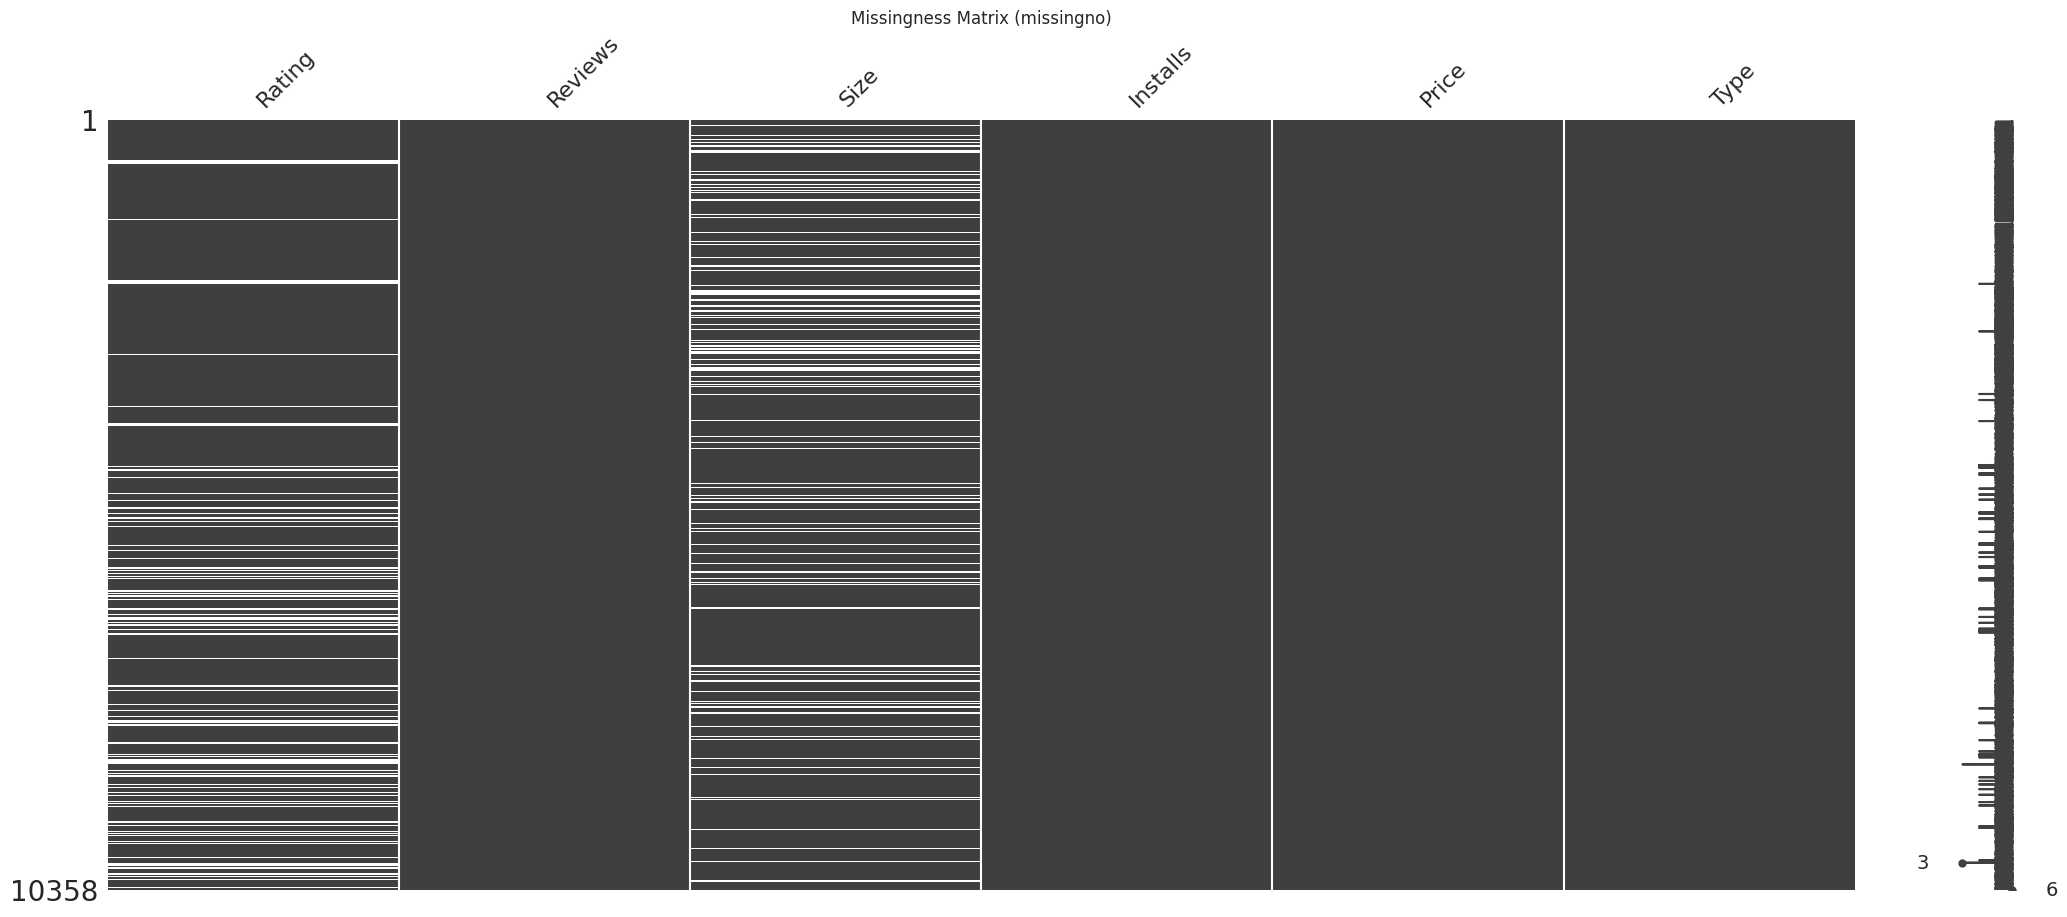

Saved missingness visualization to week3_missing_data_matrix.png
The gaps look scattered at random across rows rather than clustered in one block, which points to Missing Completely At Random (MCAR) - supporting our choice of simple median/mode imputation below.

Missing values AFTER imputation:
Rating    0
Size      0
Type      0
dtype: int64


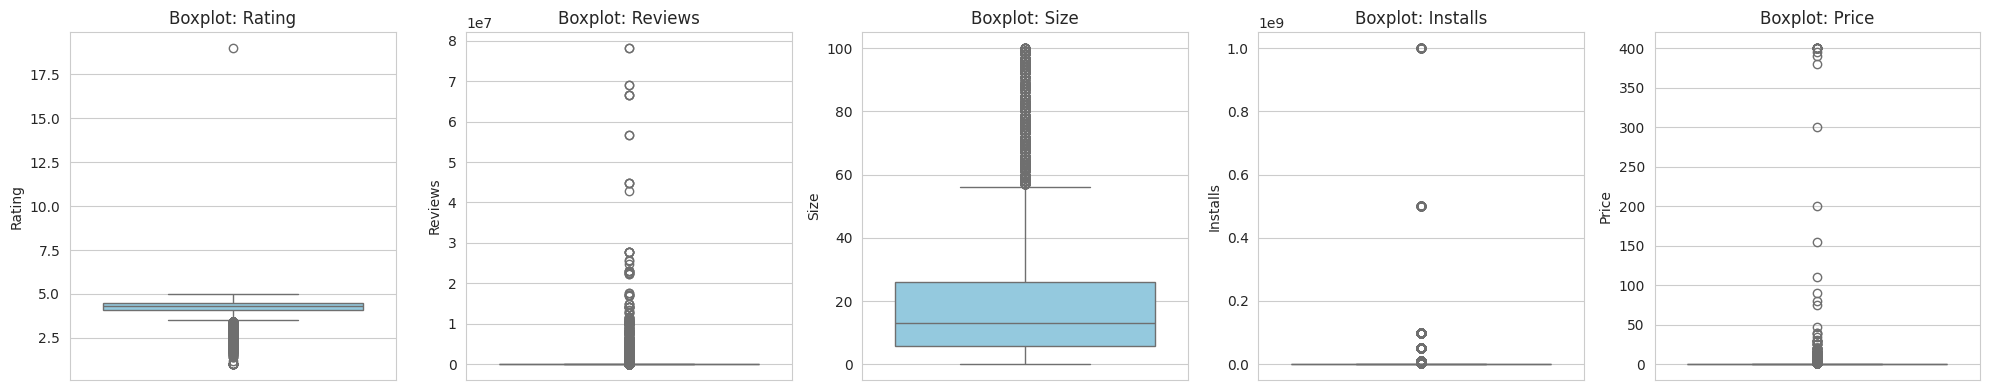


Saved boxplots to week3_boxplots.png

Outlier detection using the IQR method (Q1 - 1.5*IQR, Q3 + 1.5*IQR):
  Rating: bounds=(3.50, 5.10) -> 724 outliers
  Reviews: bounds=(-69544.00, 115992.00) -> 1870 outliers
  Size: bounds=(-24.75, 56.45) -> 831 outliers
  Installs: bounds=(-1497500.00, 2498500.00) -> 2566 outliers
  Price: bounds=(0.00, 0.00) -> 765 outliers

Outlier detection using Z-score (|z| > 3):
  Rating: 173 potential outliers
  Reviews: 98 potential outliers
  Size: 269 potential outliers
  Installs: 110 potential outliers
  Price: 23 potential outliers

Note: IQR usually flags more borderline points than Z-score on skewed columns like Installs/Price - this is expected and worth mentioning in the report as a comparison of the two methods.

Capped 'Reviews' outliers above the 99th percentile (8118905).

Cleaned dataset saved as googleplaystore_cleaned.csv
Final shape: (10358, 13)


In [2]:
"""
WEEK 3 : THE CLEANING SPRINT
Syllabus Mapping : Unit 2
----------------------------------------------------------------
Goals for this week (mapped to Unit 2 - Descriptive Statistics):
    1. Convert messy text columns (Reviews, Size, Installs, Price)
       into proper numeric columns
    2. Compute Measures of Central Tendency (Mean, Median, Mode) and
       Measures of Dispersion (Range, Variance, Std Dev, IQR) +
       Skewness/Kurtosis - this is what decides HOW we impute
    3. Visualize missing data (missingness matrix / heatmap) before
       handling it, then apply imputation strategies
    4. Detect outliers using Boxplots, the IQR method, and Z-score
    5. Save a cleaned dataset for next week's EDA
----------------------------------------------------------------
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

DATA_PATH = "googleplaystore.csv"
df = pd.read_csv(DATA_PATH)

print("Shape before cleaning:", df.shape)

# 1. REMOVE DUPLICATES

before = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {before - df.shape[0]} duplicate rows.")


# 2. CLEANING "Installs" -> numeric
#    e.g. "10,000+"  ->  10000

df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .str.replace("Free", "0", regex=False)   # safety net for stray bad values
)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")


# 3. CLEANING "Price" -> numeric
#    e.g. "$4.99" -> 4.99 , "0" -> 0.0

df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# 4. CLEANING "Size" -> numeric (in MB)
#    e.g. "19M" -> 19.0 , "Varies with device" -> NaN (imputed later)

def clean_size(value):
    value = str(value)
    if "Varies with device" in value:
        return np.nan
    if value.endswith("M"):
        return float(value.replace("M", ""))
    if value.endswith("k"):
        return float(value.replace("k", "")) / 1024   # convert KB to MB
    return np.nan

df["Size"] = df["Size"].apply(clean_size)

# 5. CLEANING "Reviews" -> numeric

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

print("\nData types after cleaning:")
print(df[["Installs", "Price", "Size", "Reviews", "Rating"]].dtypes)

# 6. DESCRIPTIVE STATISTICS: CENTRAL TENDENCY & DISPERSION
#    Mean/Median/Mode, Range/Variance/Std Dev/IQR,Skewness & Kurtosis


numeric_cols = ["Rating", "Reviews", "Size", "Installs", "Price"]

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS (before imputation)")
print("=" * 60)
desc_rows = []
for col in numeric_cols:
    series = df[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    desc_rows.append({
        "Column": col,
        "Mean": round(series.mean(), 2),
        "Median": round(series.median(), 2),
        "Mode": round(series.mode()[0], 2) if not series.mode().empty else np.nan,
        "Range": round(series.max() - series.min(), 2),
        "Variance": round(series.var(), 2),
        "Std Dev": round(series.std(), 2),
        "IQR": round(q3 - q1, 2),
        "Skewness": round(series.skew(), 2),
        "Kurtosis": round(series.kurt(), 2),
    })
desc_df = pd.DataFrame(desc_rows)
print(desc_df.to_string(index=False))
print(
    "\nReading the skewness column: values near 0 = roughly symmetric, "
    "positive = right-skewed (long tail of high values), negative = "
    "left-skewed. This is exactly why we use the MEDIAN (not the mean) "
    "to impute skewed columns like Rating and Size below."
)


# 7. MISSING DATA VISUALIZATION (before imputation)
#    Missingness Matrix / Heatmap

print("\nMissing values BEFORE imputation:")
print(df[["Rating", "Size", "Type"]].isnull().sum())

plt.figure(figsize=(10, 5))
try:
    import missingno as msno
    msno.matrix(df[["Rating", "Reviews", "Size", "Installs", "Price", "Type"]])
    plt.title("Missingness Matrix (missingno)")
except ImportError:
    # Fallback if missingno isn't installed: a boolean heatmap does the
    # same job - yellow/light cells mark a missing value in that column.
    sns.heatmap(
        df[["Rating", "Reviews", "Size", "Installs", "Price", "Type"]].isnull(),
        cbar=False, cmap="viridis"
    )
    plt.title("Missing Data Heatmap (True = missing)")
plt.tight_layout()
plt.savefig("week3_missing_data_matrix.png", dpi=150)
plt.show()
plt.close()
print("Saved missingness visualization to week3_missing_data_matrix.png")
print(
    "The gaps look scattered at random across rows rather than clustered "
    "in one block, which points to Missing Completely At Random (MCAR) - "
    "supporting our choice of simple median/mode imputation below."
)


# 8. HANDLING MISSING VALUES (Imputation)

# Rating -> numeric, skewed -> use MEDIAN (robust to outliers/skew)
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

# Size -> numeric -> use MEDIAN as well ("Varies with device" left many NaNs)
df["Size"] = df["Size"].fillna(df["Size"].median())

# Type -> categorical -> use MODE (most frequent category)
df["Type"] = df["Type"].fillna(df["Type"].mode()[0])

print("\nMissing values AFTER imputation:")
print(df[["Rating", "Size", "Type"]].isnull().sum())


# 9. OUTLIER DETECTION - BOXPLOTS (visual identification, Unit 2)

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.savefig("week3_boxplots.png", dpi=150)
plt.show()
plt.close()
print("\nSaved boxplots to week3_boxplots.png")


# 10. OUTLIER DETECTION - IQR METHOD
#     outliers are below Q1 - 1.5*IQR or above Q3 + 1.5*IQR

print("\nOutlier detection using the IQR method (Q1 - 1.5*IQR, Q3 + 1.5*IQR):")
iqr_summary = {}
for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    iqr_summary[col] = n_outliers
    print(f"  {col}: bounds=({lower_bound:.2f}, {upper_bound:.2f}) -> {n_outliers} outliers")

# 11. OUTLIER DETECTION - Z-SCORE METHOD (cross-check against IQR)

print("\nOutlier detection using Z-score (|z| > 3):")
z_summary = {}
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    n_outliers = (z_scores > 3).sum()
    z_summary[col] = n_outliers
    print(f"  {col}: {n_outliers} potential outliers")

print(
    "\nNote: IQR usually flags more borderline points than Z-score on "
    "skewed columns like Installs/Price - this is expected and worth "
    "mentioning in the report as a comparison of the two methods."
)

# Example: capping Reviews outliers at the 99th percentile
# a common strategy so that a few viral apps don't distort later analysis
upper_cap = df["Reviews"].quantile(0.99)
df["Reviews"] = np.where(df["Reviews"] > upper_cap, upper_cap, df["Reviews"])
print(f"\nCapped 'Reviews' outliers above the 99th percentile ({upper_cap:.0f}).")

# 9. SAVE CLEANED DATASET

df.to_csv("googleplaystore_cleaned.csv", index=False)
print("\nCleaned dataset saved as googleplaystore_cleaned.csv")
print("Final shape:", df.shape)

Loaded cleaned dataset. Shape: (10358, 13)


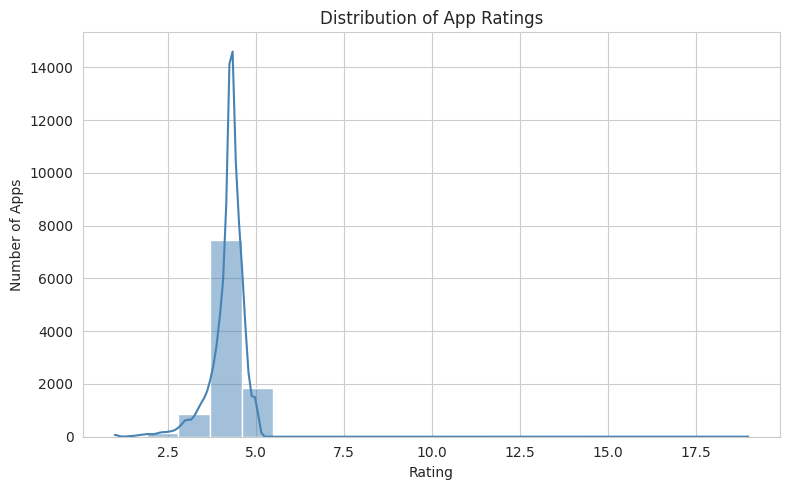

Saved: week4_univariate_rating.png


/tmp/ipykernel_1079/2914822913.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Category", data=df, order=order, palette="viridis")


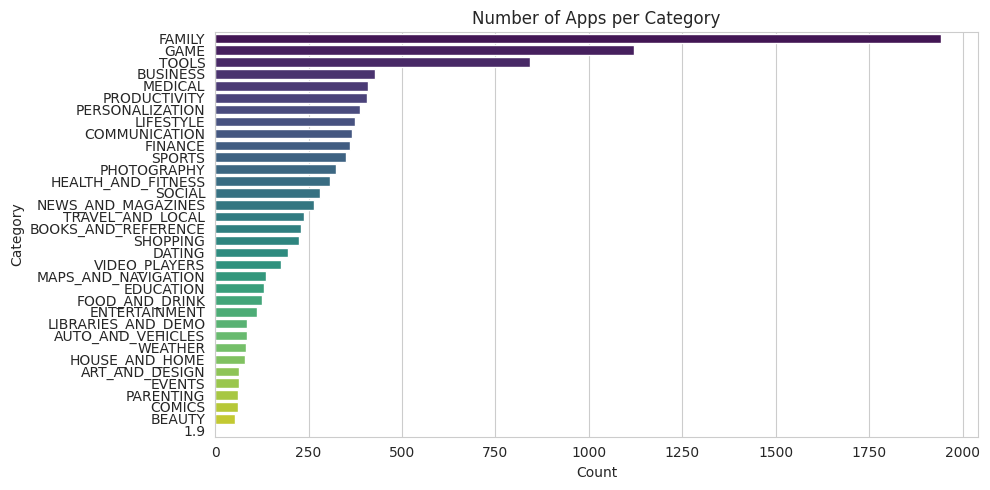

Saved: week4_univariate_category.png


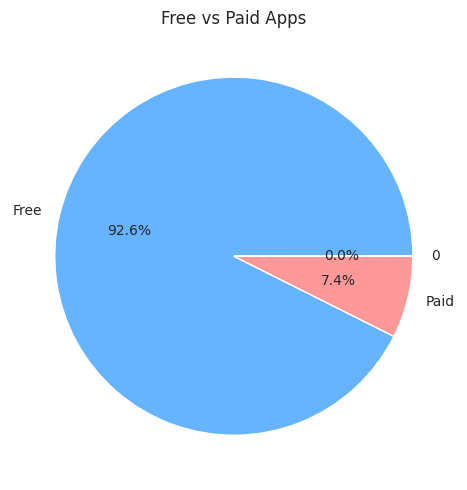

Saved: week4_univariate_type.png


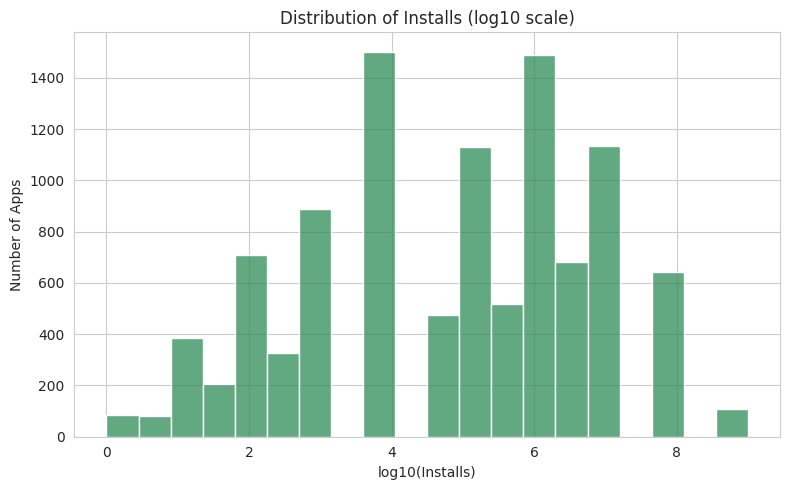

Saved: week4_univariate_installs.png


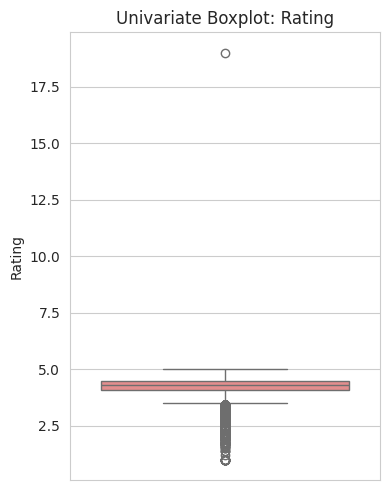

Saved: week4_univariate_rating_boxplot.png


/tmp/ipykernel_1079/2914822913.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Category", y="Rating", data=df, palette="Set2")


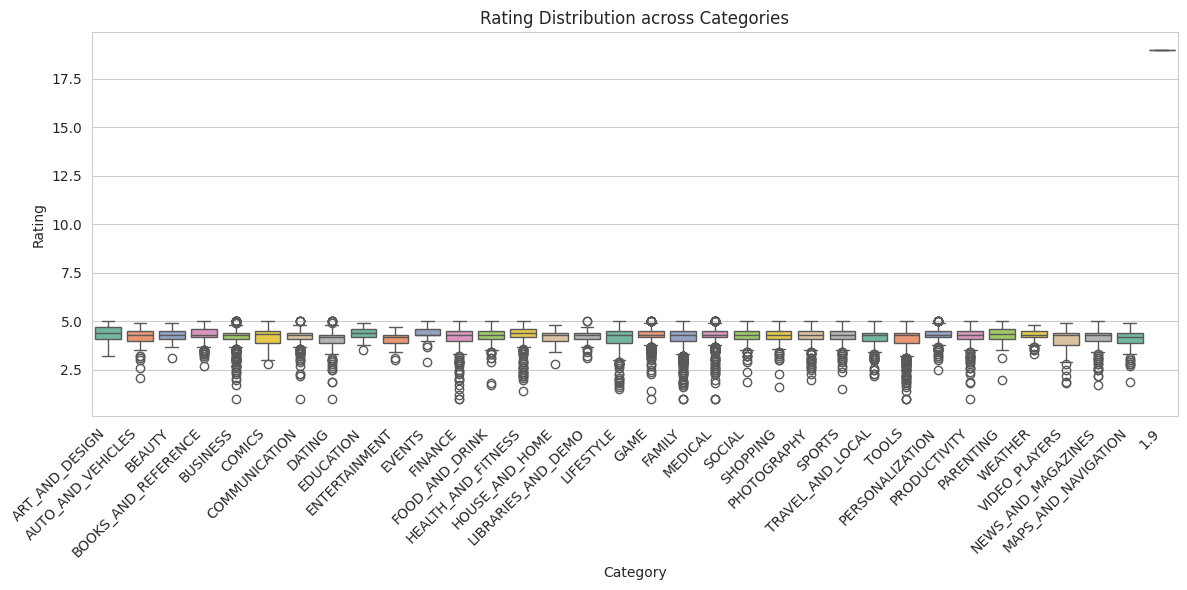

Saved: week4_bivariate_rating_category.png


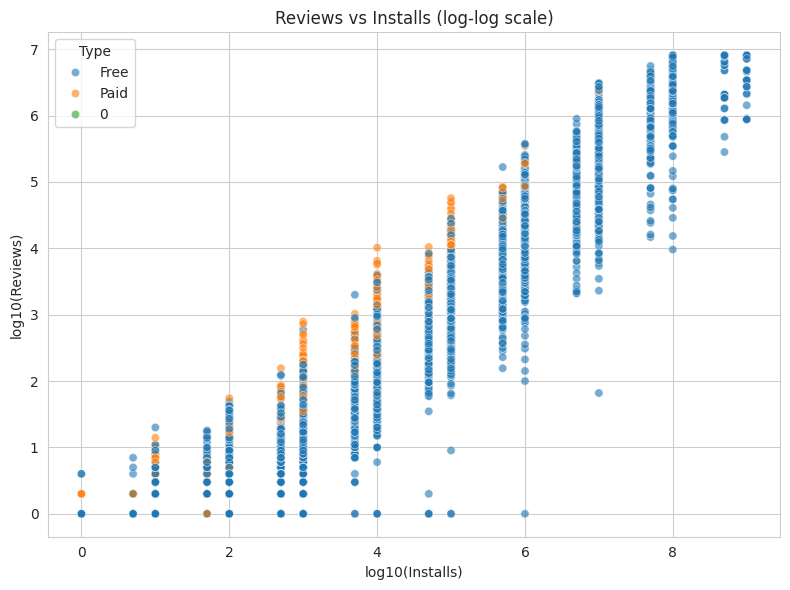

Saved: week4_bivariate_reviews_installs.png


/tmp/ipykernel_1079/2914822913.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Type", y="Rating", data=df, palette="pastel")


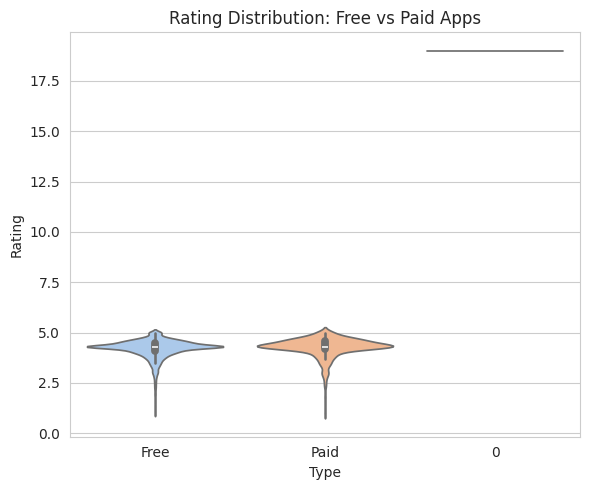

Saved: week4_bivariate_rating_type.png


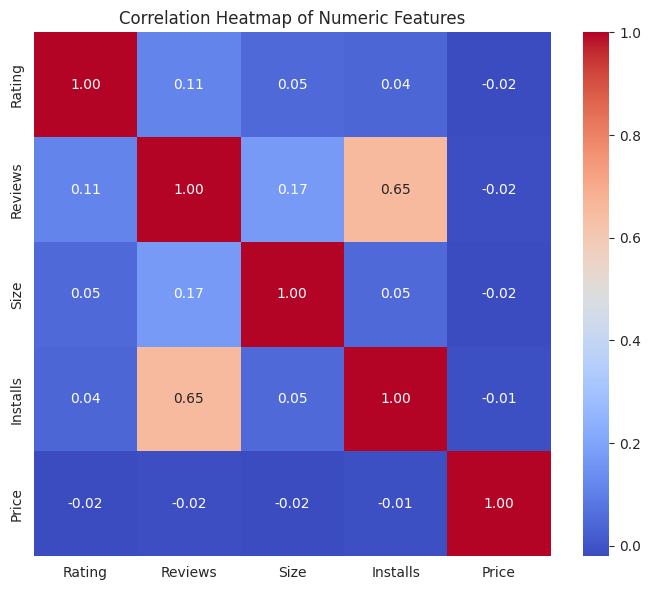

Saved: week4_correlation_heatmap.png

WEEK 4 - KEY EDA INSIGHTS
--------------------------------------------------
1. Average app rating is 4.21, and most ratings
   cluster between 4.0 and 4.5 - users tend to rate apps generously.
2. FAMILY is the most common category
   in this sample (1943 apps).
3. 92.6% of apps
   are Free, confirming a freemium-dominated market.
4. Installs and Reviews show a positive relationship on the log scale -
   apps with more installs tend to accumulate more reviews.
5. Correlation between Rating and other numeric features
   (Reviews, Size, Price, Installs) is generally weak, suggesting
   rating alone is not driven by any single numeric factor - this is
   part of the motivation for the PCA step planned in later weeks.

Saved: week4_insights.txt


In [3]:
"""
WEEK 4 : EDA DEEP DIVE
Syllabus Mapping : Unit 2 (Practical)
----------------------------------------------------------------
Goals for this week:
    1. Univariate analysis (single variable at a time)
    2. Bivariate analysis (relationship between two variables)
    3. Visualize distributions to understand app success patterns

Uses the cleaned dataset produced in Week 3
(googleplaystore_cleaned.csv). Must Run week3_cleaning_sprint.py first.
----------------------------------------------------------------
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("googleplaystore_cleaned.csv")
print("Loaded cleaned dataset. Shape:", df.shape)

# PART A : UNIVARIATE ANALYSIS

# A1. Distribution of Rating
plt.figure(figsize=(8, 5))
sns.histplot(df["Rating"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.savefig("week4_univariate_rating.png", dpi=150)
plt.show()
plt.close()
print("Saved: week4_univariate_rating.png")

# A2. Number of apps per Category
plt.figure(figsize=(10, 5))
order = df["Category"].value_counts().index
sns.countplot(y="Category", data=df, order=order, palette="viridis")
plt.title("Number of Apps per Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("week4_univariate_category.png", dpi=150)
plt.show()
plt.close()
print("Saved: week4_univariate_category.png")

# A3. Free vs Paid split
plt.figure(figsize=(5, 5))
df["Type"].value_counts().plot.pie(autopct="%1.1f%%", colors=["#66b3ff", "#ff9999"])
plt.title("Free vs Paid Apps")
plt.ylabel("")
plt.tight_layout()
plt.savefig("week4_univariate_type.png", dpi=150)
plt.show()
plt.close()
print("Saved: week4_univariate_type.png")

# A4. Distribution of Installs (log scale, since installs vary hugely)
plt.figure(figsize=(8, 5))
sns.histplot(np.log10(df["Installs"].replace(0, 1)), bins=20, color="seagreen")
plt.title("Distribution of Installs (log10 scale)")
plt.xlabel("log10(Installs)")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.savefig("week4_univariate_installs.png", dpi=150)
plt.show()
plt.close()
print("Saved: week4_univariate_installs.png")

# A5. Univariate Boxplot - Rating ( Box Plot = univariate,
#     used for outlier detection, distinct from the bivariate boxplot
#     in Part B below
plt.figure(figsize=(4, 5))
sns.boxplot(y=df["Rating"], color="lightcoral")
plt.title("Univariate Boxplot: Rating")
plt.tight_layout()
plt.savefig("week4_univariate_rating_boxplot.png", dpi=150)
plt.show()
plt.close()
print("Saved: week4_univariate_rating_boxplot.png")

# PART B : BIVARIATE ANALYSIS

# B1. Rating vs Category (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x="Category", y="Rating", data=df, palette="Set2")
plt.title("Rating Distribution across Categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("week4_bivariate_rating_category.png", dpi=150)
plt.show()
plt.close()
print("Saved: week4_bivariate_rating_category.png")

# B2. Reviews vs Installs (scatter, log-log since both are skewed)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=np.log10(df["Installs"].replace(0, 1)),
    y=np.log10(df["Reviews"].replace(0, 1)),
    hue=df["Type"],
    alpha=0.6,
)
plt.title("Reviews vs Installs (log-log scale)")
plt.xlabel("log10(Installs)")
plt.ylabel("log10(Reviews)")
plt.tight_layout()
plt.savefig("week4_bivariate_reviews_installs.png", dpi=150)
plt.show()
plt.close()
print("Saved: week4_bivariate_reviews_installs.png")

# B3. Rating vs Type (Free vs Paid)
plt.figure(figsize=(6, 5))
sns.violinplot(x="Type", y="Rating", data=df, palette="pastel")
plt.title("Rating Distribution: Free vs Paid Apps")
plt.tight_layout()
plt.savefig("week4_bivariate_rating_type.png", dpi=150)
plt.show()
plt.close()
print("Saved: week4_bivariate_rating_type.png")

# B4. Correlation heatmap of numeric features
plt.figure(figsize=(7, 6))
numeric_df = df[["Rating", "Reviews", "Size", "Installs", "Price"]]
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("week4_correlation_heatmap.png", dpi=150)
plt.show()
plt.close()
print("Saved: week4_correlation_heatmap.png")

# PART C : KEY INSIGHTS SUMMARY

insights = f"""
WEEK 4 - KEY EDA INSIGHTS
--------------------------------------------------
1. Average app rating is {df['Rating'].mean():.2f}, and most ratings
   cluster between 4.0 and 4.5 - users tend to rate apps generously.
2. {df['Category'].value_counts().idxmax()} is the most common category
   in this sample ({df['Category'].value_counts().max()} apps).
3. {(df['Type'].value_counts(normalize=True)['Free']*100):.1f}% of apps
   are Free, confirming a freemium-dominated market.
4. Installs and Reviews show a positive relationship on the log scale -
   apps with more installs tend to accumulate more reviews.
5. Correlation between Rating and other numeric features
   (Reviews, Size, Price, Installs) is generally weak, suggesting
   rating alone is not driven by any single numeric factor - this is
   part of the motivation for the PCA step planned in later weeks.
"""
print(insights)
with open("week4_insights.txt", "w") as f:
    f.write(insights)
print("Saved: week4_insights.txt")